In [1]:
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import mplhep as hep
from itertools import product
plt.style.use(hep.style.ATLAS)

from utils import add_project_root_to_sys_path
add_project_root_to_sys_path()

from neuralnet.datasets import ParquetDataset
import numpy as np

In [2]:
dataset = ParquetDataset(dataset_dir='/home/lucasbanunes/data/ringer-datasets/datasets/mc21_isabela_qt_2sigma_restriction')
data_df = pl.scan_parquet(dataset.get_table_glob('data'))
qat_df = pl.scan_parquet(dataset.get_table_glob('vqat0')).select('id', pl.col('prediction').alias('qat.prediction'))
fp_df = pl.scan_parquet(dataset.get_table_glob('mlp0')).select('id', pl.col('prediction').alias('fp.prediction'))
binning_df = pl.scan_parquet(dataset.get_table_glob('standard_binning_kfold'))
ptq_df = pl.scan_parquet('~/data/ringer-datasets/output_noq.parquet').select(
    pl.col('Sigmoid').alias('ptq.prediction'),
    pl.col('Target').alias('label')
).collect()

In [3]:
binning_df.collect_schema()

Schema([('id', UInt64), ('label', Boolean), ('kfold', UInt8)])

In [3]:
plot_df_query = fp_df.join(
    binning_df, on='id', how='inner'
).join(
    qat_df, on='id', how='inner'
).select(
    'fp.prediction', 'qat.prediction', 'label'
).filter(
    pl.col('label').is_not_null()
)
plot_df_query.collect_schema()

Schema([('fp.prediction', Float32),
        ('qat.prediction', Float32),
        ('label', Boolean)])

In [4]:
plot_df = plot_df_query.collect()
plot_df

fp.prediction,qat.prediction,label
f32,f32,bool
0.007153,0.001971,false
0.001101,0.000114,false
0.000655,0.000324,false
0.001208,0.000701,false
0.00004,0.000033,false
…,…,…
0.386734,0.438597,false
0.558765,0.496487,true
0.54275,0.558479,true


In [5]:
hist_columns = {
    'fp.prediction': {
        'label': 'FP',
        'marker': 'o',
        'linestyle': '-',
        'df': plot_df,
    },
    'qat.prediction': {
        'label': 'QAT',
        'df': plot_df,
        'marker': '^',
        'linestyle': '--'
    },
    'ptq.prediction': {
        'label': 'PTQ',
        'df': ptq_df,
        'col': 'ptq.prediction',
        'marker': 's',
        'linestyle': '-.'
    }
}

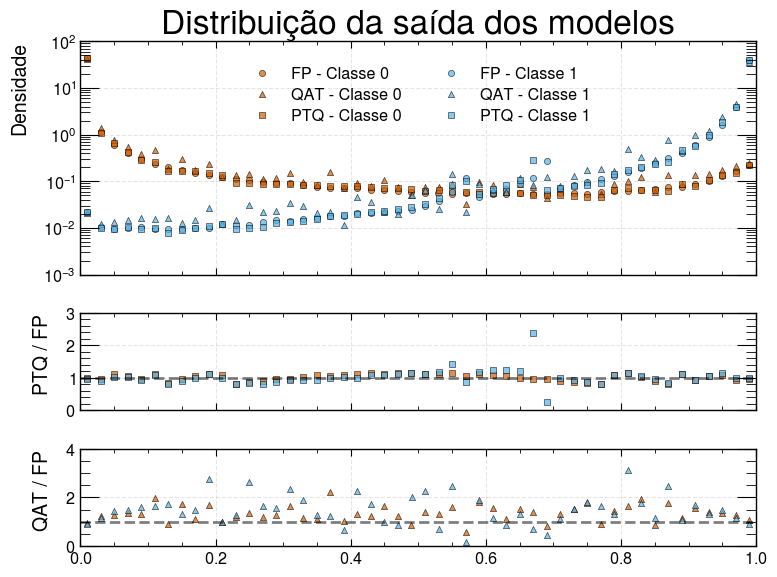

In [15]:
fig = plt.figure(layout="tight")
grid_spec = GridSpec(8, 1, figure=fig)
hist_ax = fig.add_subplot(grid_spec[:4, 0])
# fig, ax = plt.subplots(3, 1)
hist_ax.grid(linestyle='--', alpha=0.1, color='k')
colors = [
    'red',
    'blue',
    'green',
    'orange',
    'purple',
    'cyan',
    'magenta',
]
class_colors = [
    'C0',
    'C1'
]
for i, (class_label, hist_col) in enumerate(product(range(2), hist_columns)):
    hist_config = hist_columns[hist_col]
    color = class_colors[class_label]
    n, bins = np.histogram(
        hist_config['df'].filter(pl.col('label') == class_label)[hist_col].to_numpy(),
        bins=50,
        density=True
    )
    # n, bins, _ =  ax.hist(
    #     hist_config['df'].filter(pl.col('label') == class_label)[hist_col].to_numpy(),
    #     bins=50,
    #     alpha=0.5,
    #     linestyle=hist_config['linestyle'],
    #     color='white',
    #     label=None,
    #     histtype='step',
    #     linewidth=2,
    #     density=True
    # )
    x = (bins[:-1] + bins[1:])/2
    y = n

    hist_ax.scatter(
        x, y,
        color=color,
        s=20,
        alpha=0.7,
        edgecolor='k',
        linewidth=0.5,
        marker=hist_config['marker'],
        label=f"{hist_config['label']} - Classe {class_label}"
    )
    hist_columns[hist_col][f'y_class_{class_label}'] = y
    hist_columns[hist_col][f'x_class_{class_label}'] = x
# hist_ax.set_xlabel('Saída do Modelo', fontsize='small')
hist_ax.set_ylabel('Densidade', fontsize='medium')
hist_ax.set_yscale('log')
hist_ax.set_title('Distribuição da saída dos modelos')
hist_ax.legend(
    fontsize='small',
    loc='upper center',
    ncols=2
)
hist_ax.tick_params(
    axis='x',          # Apply to x and y axes
    which='both',        # Target major ticks
    # bottom=False,
    labelbottom=False
)
hist_ax.tick_params(
    axis='y',          # Apply to x and y axes
    which='both',        # Target major ticks
    # bottom=False,
    labelsize='small'
)

classes_ratios = {
    'PTQ / FP': {
        'ax': fig.add_subplot(grid_spec[4:6, 0]),
        'numerator': 'ptq.prediction',
        'denominator': 'fp.prediction',
        'tick_params':[
            {'axis': 'x', 'which': 'both', 'labelbottom': False},
            {'axis': 'y', 'which': 'both', 'labelsize': 'small'}
        ]
    },
    'QAT / FP': {
        'ax': fig.add_subplot(grid_spec[6:8, 0]),
        'numerator': 'qat.prediction',
        'denominator': 'fp.prediction',
        'tick_params':[
            {'axis': 'x', 'which': 'both', 'labelsize': 'small'},
            {'axis': 'y', 'which': 'both', 'labelsize': 'small'}
        ]
    }
}

for ratio_label, ratio_config in classes_ratios.items():
    ratio_ax = ratio_config['ax']
    ratio_ax.grid(linestyle='--', alpha=0.1, color='k')
    ratio_ax.set_ylabel(ratio_label, fontsize='medium')
    ratio_ax.axhline(1, color='k', linestyle='--', alpha=0.5)
    for param in ratio_config['tick_params']:
        ratio_ax.tick_params(**param)
    for color, class_label in zip (class_colors, range(2)):
        
        numerator_config = hist_columns[ratio_config['numerator']]
        denominator_config = hist_columns[ratio_config['denominator']]
        ptq_fp_ratio = numerator_config[f'y_class_{class_label}'] / denominator_config[f'y_class_{class_label}']
        ratio_ax.scatter(
            numerator_config[f'x_class_{class_label}'], ptq_fp_ratio,
            color=color,
            s=20,
            alpha=0.7,
            edgecolor='k',
            linewidth=0.5,
            marker=numerator_config['marker'],
            label=f'Classe {class_label}'
        )

    # ratio_ax.legend(
    #     fontsize='small',
    #     # loc='upper center',
    #     ncols=3
    # )


fig.tight_layout()

In [16]:
fig.savefig('sbrt_comparison.png', dpi=300)